In [99]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset as TorchDataset
from torch.utils.data import DataLoader as TorchDataLoader
from torch_geometric.data import Data, Dataset as PyGDataset
from torch_geometric.loader import DataLoader as PyGDataLoader




class GraphDataset(PyGDataset):
    """
    Custom PyTorch Geometric Dataset loading all data frames 
    with index-level row alignment per subject.
    """
    def __init__(
        self,
        args,
        subjects_df,
        mod_a_df,
        mod_b_df,
        labels_df,
        sims_score_df,
    ):
        super().__init__()
    
        # args
        self.mod_a = args.modality.include_mod_a
        self.mod_b = args.modality.include_mod_b

        self.mod_a_df = mod_a_df
        self.mod_b_df = mod_b_df
        self.adj_path = os.path.join(args.data, "adjacency")
        self.adjacency_mode = getattr(args, "adjacency_mode", "real")
    
    
        # dataframes
        self.subjects_df = subjects_df.reset_index(drop=True)
        self.labels_df = labels_df.drop("resected",axis=1) # not to include while training
        self.labels_df["uid"] = (
            self.labels_df["subject_id"].astype(str)
                + "_"
                + self.labels_df["node_id"].astype(str)
            )
        self.mod_a_df["uid"] = (
                        self.mod_a_df["subject_id"].astype(str)
                        + "_"
                        + self.mod_a_df["node_id"].astype(str)
                    )
        self.mod_b_df["uid"] = (
                        self.mod_b_df["subject_id"].astype(str)
                        + "_"
                        + self.mod_b_df["node_id"].astype(str)
                    )
        self.sims_score_df = sims_score_df # for post processing 
    
        self.mod_a_features = ["ct_z","gmv_z","sa_z","curv_z","t1t2_z","lgi_z"] 
        self.mod_b_features = ["rel_delta",	"rel_theta", "rel_alpha", "rel_beta", "rel_gamma", "spike_rate", "hfo_rate"]
            
            
    
        self.node_level_features = self.labels_df.copy()
        if self.mod_a:
            self.node_level_features = self.node_level_features.merge(
                    self.mod_a_df[["uid", *self.mod_a_features]], on="uid", how="inner"
                )

        if self.mod_b:
            self.node_level_features = self.node_level_features.merge(
                    self.mod_b_df[["uid", *self.mod_b_features]], on="uid", how="inner"
                )

        self.feature_columns = []
        if self.mod_a:
            self.feature_columns.extend(self.mod_a_features)
        if self.mod_b:
            self.feature_columns.extend(self.mod_b_features)
        if not self.feature_columns:
            raise ValueError("At least one modality must be enabled for GraphDataset.")

    def len(self):
        return len(self.subjects_df)

    def get(self, idx):
        subject_id = self.subjects_df.iloc[idx]["subject_id"]
        adjacency = np.asarray(
            np.load(os.path.join(self.adj_path, f"{subject_id}_adj.npy")),
            dtype=np.float32,
        )
        if adjacency.shape != (68, 68):
            raise ValueError(f"Expected a 68x68 adjacency matrix for {subject_id}.")

        subject_rows = self.node_level_features[
            self.node_level_features["subject_id"] == subject_id
        ].sort_values("node_id")
        if len(subject_rows) != 68 or not np.array_equal(
            subject_rows["node_id"].to_numpy(), np.arange(68)
        ):
            raise ValueError(f"Expected 68 aligned nodes for {subject_id}.")

        if self.adjacency_mode == "identity":
            adjacency = np.eye(68, dtype=np.float32)
            node_order = np.arange(68)
        elif self.adjacency_mode == "shuffled":
            rng = np.random.default_rng(100 + idx)
            node_order = rng.permutation(68)
            adjacency = adjacency[np.ix_(node_order, node_order)]
        elif self.adjacency_mode == "real":
            node_order = np.arange(68)
        else:
            raise ValueError(f"Unknown adjacency mode: {self.adjacency_mode}")

        subject_rows = subject_rows.iloc[node_order].reset_index(drop=True)
        node_features = subject_rows[self.feature_columns].to_numpy(dtype=np.float32)
        if not np.isfinite(node_features).all():
            raise ValueError(f"Missing or invalid node feature for {subject_id}.")

        adjacency = np.maximum(adjacency, adjacency.T)
        upper_edges = np.argwhere(np.triu(adjacency, k=1) > 0)
        reverse_edges = upper_edges[:, [1, 0]]
        edge_pairs = np.vstack((upper_edges, reverse_edges))
        edge_index = torch.tensor(edge_pairs.T, dtype=torch.long)
        edge_weight = torch.tensor(
            adjacency[edge_pairs[:, 0], edge_pairs[:, 1]], dtype=torch.float32
        )
        labels = torch.tensor(
            subject_rows["is_abnormal"].to_numpy(), dtype=torch.long
        )

        data = Data(
            x=torch.tensor(node_features),
            edge_index=edge_index,
            edge_weight=edge_weight,
            y=labels,
            node_id=torch.tensor(node_order, dtype=torch.long),
        )

        data.subject_id = subject_id
        return data
    




In [100]:
# Load one project configuration and create the split graph loaders.
from argparse import Namespace
from pathlib import Path
import yaml

from src.datahandler import DataLoader

project_root = Path.cwd()
config_path = project_root / "src" / "args" / "args_gcn_multimodal_ident.yml"

with config_path.open() as config_file:
    config = yaml.safe_load(config_file)

args = Namespace(**config)
args.modality = Namespace(**config["modality"])
args.data = str(project_root / "data")
args.adjacency_mode = "identity"
args.shuffle_seed = 0


args

dl = DataLoader(args)


In [103]:
subjects_df = pd.read_csv(os.path.join(args.data, "subjects.csv"))
mod_a_df = pd.read_csv(os.path.join(args.data, "modality_A.csv"))
mod_b_df = pd.read_csv(os.path.join(args.data, "modality_B.csv"))
labels_df = pd.read_csv(os.path.join(args.data, "node_labels.csv"))
sims_score_df = pd.read_csv(os.path.join(args.data, "simulation_scores.csv"))

ds = GraphDataset(
    args=args,
    subjects_df=subjects_df,
    mod_a_df=dl.null_handler_a(mod_a_df),
    mod_b_df=dl.null_handler_b(mod_b_df, subjects_df["subject_id"]),
    labels_df=labels_df,
    sims_score_df=sims_score_df,
)

In [104]:
ds.node_level_features # should have 9520

,subject_id,node_id,region,is_abnormal,uid,ct_z,gmv_z,sa_z,curv_z,t1t2_z,lgi_z,rel_delta,rel_theta,rel_alpha,rel_beta,rel_gamma,spike_rate,hfo_rate
0,sub-000,0,L_bankssts,0,sub-000_0,-0.609551,1.711434,-0.225632,1.847527,0.538214,-0.602805,-0.449369,1.009385,-0.981143,0.628724,-0.969271,3.092685,5.148189
1,sub-000,1,L_caudalanteriorcingulate,0,sub-000_1,-0.014400,1.362900,0.830090,0.000000,0.604231,0.896440,1.091413,-0.172999,-0.607435,-0.573459,-0.006783,2.775620,2.909485
2,sub-000,2,L_caudalmiddlefrontal,1,sub-000_2,-0.827773,-0.188509,-0.289699,-1.069580,0.620630,-0.046198,0.412656,0.642449,-0.373071,-0.636460,1.407681,9.340972,5.064601
3,sub-000,3,L_cuneus,0,sub-000_3,-1.032756,-0.086454,-1.486465,-0.432962,0.488979,0.535247,0.409062,1.452943,-1.036706,-1.180486,0.536428,2.781998,2.386240
4,sub-000,4,L_entorhinal,0,sub-000_4,-0.428911,0.033223,0.000000,0.473602,0.000000,0.051591,1.215344,0.902558,-0.347023,-1.815927,-0.430801,4.513502,8.456669
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9515,sub-139,63,R_supramarginal,0,sub-139_63,-1.861685,-1.979099,-1.383101,0.704567,-0.063021,-1.072607,-1.385785,0.541866,0.144054,-1.002338,0.911854,14.751339,8.875106
9516,sub-139,64,R_frontalpole,0,sub-139_64,-2.895157,-2.944210,0.568335,-0.834158,0.650545,0.113607,-0.639627,-0.485309,0.081362,-1.582709,0.520220,15.203189,25.770678
9517,sub-139,65,R_temporalpole,0,sub-139_65,0.335951,-1.251053,0.511067,0.840015,0.047673,0.577498,0.458121,-0.378166,-0.393688,-0.200954,1.849871,4.606524,3.366959
9518,sub-139,66,R_transversetemporal,0,sub-139_66,-0.678288,0.718370,-0.509538,-1.870276,-0.873434,-1.119473,0.252469,2.391520,-0.934268,-1.659010,1.346930,1.747426,6.263906


In [ ]:
ds.node_level_features["is_abnormal"].value_counts() 

is_abnormal
0    8828
1     692
Name: count, dtype: int64

In [108]:
subject_id = ds.subjects_df.iloc[0]["subject_id"]
adjacency = np.asarray(np.load(os.path.join(ds.adj_path, f"{subject_id}_adj.npy")),dtype=np.float32)
        
subject_rows = ds.node_level_features[
            ds.node_level_features["subject_id"] == subject_id
        ].sort_values("node_id")


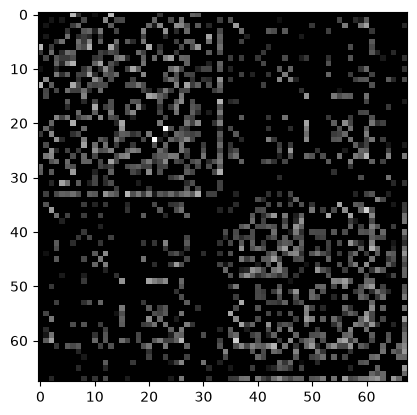

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
plt.imshow(adjacency, cmap="grey") # black is 0
plt.show()

In [116]:
subject_rows

,subject_id,node_id,region,is_abnormal,uid,ct_z,gmv_z,sa_z,curv_z,t1t2_z,lgi_z,rel_delta,rel_theta,rel_alpha,rel_beta,rel_gamma,spike_rate,hfo_rate
0,sub-000,0,L_bankssts,0,sub-000_0,-0.609551,1.711434,-0.225632,1.847527,0.538214,-0.602805,-0.449369,1.009385,-0.981143,0.628724,-0.969271,3.092685,5.148189
1,sub-000,1,L_caudalanteriorcingulate,0,sub-000_1,-0.014400,1.362900,0.830090,0.000000,0.604231,0.896440,1.091413,-0.172999,-0.607435,-0.573459,-0.006783,2.775620,2.909485
2,sub-000,2,L_caudalmiddlefrontal,1,sub-000_2,-0.827773,-0.188509,-0.289699,-1.069580,0.620630,-0.046198,0.412656,0.642449,-0.373071,-0.636460,1.407681,9.340972,5.064601
3,sub-000,3,L_cuneus,0,sub-000_3,-1.032756,-0.086454,-1.486465,-0.432962,0.488979,0.535247,0.409062,1.452943,-1.036706,-1.180486,0.536428,2.781998,2.386240
4,sub-000,4,L_entorhinal,0,sub-000_4,-0.428911,0.033223,0.000000,0.473602,0.000000,0.051591,1.215344,0.902558,-0.347023,-1.815927,-0.430801,4.513502,8.456669
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,sub-000,63,R_supramarginal,0,sub-000_63,-0.855520,0.133591,-0.607589,-0.547326,-0.486021,-1.427541,0.427498,0.624166,-1.132173,0.529427,-0.944039,13.114034,2.868571
64,sub-000,64,R_frontalpole,0,sub-000_64,-0.818017,1.163123,0.152017,-0.174431,-0.307684,0.886259,-0.313759,0.869237,-0.528596,-0.232561,0.701984,6.023072,7.929817
65,sub-000,65,R_temporalpole,0,sub-000_65,1.982058,-0.314014,0.663714,1.208664,-0.394048,1.546381,0.027818,0.726869,-0.188311,-1.029020,0.615363,4.621620,4.429000
66,sub-000,66,R_transversetemporal,0,sub-000_66,-0.173099,0.300616,-0.036801,0.206020,0.758214,2.268957,-1.288464,1.198821,-0.213876,-0.116681,1.468810,27.674642,12.784880


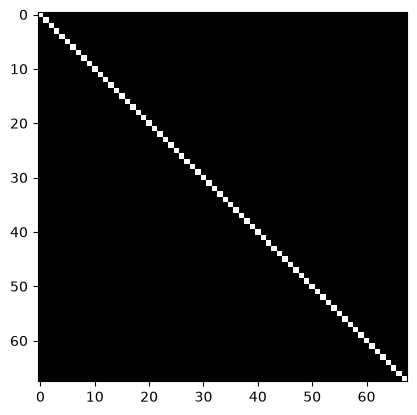

In [120]:
# For identity

adjacency = np.eye(68, dtype=np.float32)
node_order = np.arange(68)

plt.imshow(adjacency, cmap="grey") # black is 0
plt.show()

In [121]:
node_order

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67])

In [125]:
subject_rows = subject_rows.iloc[node_order].reset_index(drop=True)
node_features = subject_rows[ds.feature_columns].to_numpy(dtype=np.float32)

In [131]:
subject_rows

,subject_id,node_id,region,is_abnormal,uid,ct_z,gmv_z,sa_z,curv_z,t1t2_z,lgi_z,rel_delta,rel_theta,rel_alpha,rel_beta,rel_gamma,spike_rate,hfo_rate
0,sub-000,0,L_bankssts,0,sub-000_0,-0.609551,1.711434,-0.225632,1.847527,0.538214,-0.602805,-0.449369,1.009385,-0.981143,0.628724,-0.969271,3.092685,5.148189
1,sub-000,1,L_caudalanteriorcingulate,0,sub-000_1,-0.014400,1.362900,0.830090,0.000000,0.604231,0.896440,1.091413,-0.172999,-0.607435,-0.573459,-0.006783,2.775620,2.909485
2,sub-000,2,L_caudalmiddlefrontal,1,sub-000_2,-0.827773,-0.188509,-0.289699,-1.069580,0.620630,-0.046198,0.412656,0.642449,-0.373071,-0.636460,1.407681,9.340972,5.064601
3,sub-000,3,L_cuneus,0,sub-000_3,-1.032756,-0.086454,-1.486465,-0.432962,0.488979,0.535247,0.409062,1.452943,-1.036706,-1.180486,0.536428,2.781998,2.386240
4,sub-000,4,L_entorhinal,0,sub-000_4,-0.428911,0.033223,0.000000,0.473602,0.000000,0.051591,1.215344,0.902558,-0.347023,-1.815927,-0.430801,4.513502,8.456669
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,sub-000,63,R_supramarginal,0,sub-000_63,-0.855520,0.133591,-0.607589,-0.547326,-0.486021,-1.427541,0.427498,0.624166,-1.132173,0.529427,-0.944039,13.114034,2.868571
64,sub-000,64,R_frontalpole,0,sub-000_64,-0.818017,1.163123,0.152017,-0.174431,-0.307684,0.886259,-0.313759,0.869237,-0.528596,-0.232561,0.701984,6.023072,7.929817
65,sub-000,65,R_temporalpole,0,sub-000_65,1.982058,-0.314014,0.663714,1.208664,-0.394048,1.546381,0.027818,0.726869,-0.188311,-1.029020,0.615363,4.621620,4.429000
66,sub-000,66,R_transversetemporal,0,sub-000_66,-0.173099,0.300616,-0.036801,0.206020,0.758214,2.268957,-1.288464,1.198821,-0.213876,-0.116681,1.468810,27.674642,12.784880


In [130]:
node_features

array([[-6.09550834e-01,  1.71143353e+00, -2.25632116e-01,
         1.84752703e+00,  5.38213849e-01, -6.02805197e-01,
        -4.49368805e-01,  1.00938487e+00, -9.81142521e-01,
         6.28724098e-01, -9.69271362e-01,  3.09268546e+00,
         5.14818954e+00],
       [-1.44003192e-02,  1.36289954e+00,  8.30089748e-01,
         0.00000000e+00,  6.04231060e-01,  8.96439791e-01,
         1.09141254e+00, -1.72999337e-01, -6.07434571e-01,
        -5.73459029e-01, -6.78265700e-03,  2.77562022e+00,
         2.90948462e+00],
       [-8.27773213e-01, -1.88508749e-01, -2.89699078e-01,
        -1.06958032e+00,  6.20630443e-01, -4.61984798e-02,
         4.12655979e-01,  6.42449498e-01, -3.73070627e-01,
        -6.36460483e-01,  1.40768123e+00,  9.34097195e+00,
         5.06460094e+00],
       [-1.03275573e+00, -8.64539295e-02, -1.48646498e+00,
        -4.32962269e-01,  4.88978624e-01,  5.35246491e-01,
         4.09061849e-01,  1.45294261e+00, -1.03670633e+00,
        -1.18048608e+00,  5.36427915e

In [ ]:
adjacency = np.maximum(adjacency, adjacency.T)
upper_edges = np.argwhere(np.triu(adjacency, k=1) > 0)
reverse_edges = upper_edges[:, [1, 0]]

edge_pairs = np.vstack((upper_edges, reverse_edges))
edge_index = torch.tensor(edge_pairs.T, dtype=torch.long)
edge_weight = torch.tensor(
            adjacency[edge_pairs[:, 0], edge_pairs[:, 1]], dtype=torch.float32
        )

labels = torch.tensor(
            subject_rows["is_abnormal"].to_numpy(), dtype=torch.long
        )
